In [93]:
import matplotlib.pyplot as plt
import json
import sys
import os
from pathlib import Path
import numpy as np
import networkx as nx

In [97]:
# hamiltonian_class = "H4_linear"
# geometries = [1.089, 2.067, 2.556, 4.022]

hamiltonian_class = "H2O_OH"
geometries = [0.958, 1.643, 2.5]

hamiltonians = list(Path("../hamiltonians/").glob(hamiltonian_class + "*"))
hamiltonian_names = sorted([q.name for q in hamiltonians])
print(hamiltonian_names)

bond_length = dict(zip(hamiltonian_names, geometries))
print(bond_length)

['H2O_OH0.9580_104.5000.chk', 'H2O_OH1.6430_104.5000.chk', 'H2O_OH2.5000_104.5000.chk']
{'H2O_OH0.9580_104.5000.chk': 0.958, 'H2O_OH1.6430_104.5000.chk': 1.643, 'H2O_OH2.5000_104.5000.chk': 2.5}


In [98]:
p = Path("../outputs/quartets/")
quartet_data_paths = []
for name in hamiltonian_names:
    quartet_data_paths += list(p.glob("quartets_" + name + "*"))

quartet_data_paths = sorted(quartet_data_paths)
quartet_data_paths

[PosixPath('../outputs/quartets/quartets_H2O_OH0.9580_104.5000.chk_10f06e'),
 PosixPath('../outputs/quartets/quartets_H2O_OH0.9580_104.5000.chk_8df775'),
 PosixPath('../outputs/quartets/quartets_H2O_OH0.9580_104.5000.chk_d8b0f3'),
 PosixPath('../outputs/quartets/quartets_H2O_OH1.6430_104.5000.chk_3e9bd5'),
 PosixPath('../outputs/quartets/quartets_H2O_OH1.6430_104.5000.chk_b17f67'),
 PosixPath('../outputs/quartets/quartets_H2O_OH1.6430_104.5000.chk_dff4b8'),
 PosixPath('../outputs/quartets/quartets_H2O_OH2.5000_104.5000.chk_3368f7'),
 PosixPath('../outputs/quartets/quartets_H2O_OH2.5000_104.5000.chk_81333c'),
 PosixPath('../outputs/quartets/quartets_H2O_OH2.5000_104.5000.chk_99d7ee')]

In [99]:
quartet_data = []
for qp in quartet_data_paths:
    with open(qp, "r") as fp:
        quartet_data.append(json.load(fp))

In [100]:
for q in quartet_data:
    g = nx.Graph(q["lowest_nc_quartets"])
    print(nx.is_tree(g))

False
False
False
False
False
False
False
False
False


In [101]:
no_opt_results = [q for q in quartet_data 
                  if (q["vars"]["optimization_mode"] is None)]

In [102]:
no_opt_K_overlap = [q["sector_data"]["K_overlap"] for q in no_opt_results]
no_opt_K_en = [q["sector_data"]["K_en"] for q in no_opt_results]
no_opt_bonds = [bond_length[
                Path(q["vars"]["molpath"]).name
               ]
                for q in no_opt_results
               ]

no_opt_decoupled_ens = np.array([q["sector_data"]["Decoupled_energy"] for q in no_opt_results])
no_opt_bo_ens = np.array([q["sector_data"]["BO energy"] for q in no_opt_results])

In [103]:
fci_ens = np.array([q["FCI energy"] for q in no_opt_results])

In [104]:
matching_opt_results = [q for q in quartet_data 
                  if (q["vars"]["optimization_mode"]=="OO"
                     and q["vars"]["quartet_graph"]=="matching"
                     and q["vars"]["initial_guess"] is None)]

matching_opt_K_overlap = [q["sector_data"]["K_overlap"] for q in matching_opt_results]
matching_opt_K_en = [q["sector_data"]["K_en"] for q in matching_opt_results]
matching_opt_bonds = [bond_length[
                Path(q["vars"]["molpath"]).name
               ]
                for q in matching_opt_results
               ]

matching_opt_decoupled_ens = np.array([q["sector_data"]["Decoupled_energy"] 
                                       for q in matching_opt_results])
matching_opt_bo_ens = np.array([q["sector_data"]["BO energy"] 
                                for q in matching_opt_results])

ring_opt_results = [q for q in quartet_data 
                  if (q["vars"]["optimization_mode"]=="OO"
                     and q["vars"]["quartet_graph"]=="ring"
                     and q["vars"]["initial_guess"] is None)]

ring_opt_K_overlap = [q["sector_data"]["K_overlap"] for q in ring_opt_results]
ring_opt_K_en = [q["sector_data"]["K_en"] for q in ring_opt_results]
ring_opt_bonds = [bond_length[
                Path(q["vars"]["molpath"]).name
               ]
                for q in ring_opt_results
               ]

ring_opt_decoupled_ens = np.array([q["sector_data"]["Decoupled_energy"] 
                                   for q in ring_opt_results])
ring_opt_bo_ens = np.array([q["sector_data"]["BO energy"] 
                            for q in ring_opt_results])

In [105]:
plt.rcParams.update({"font.size": 13})

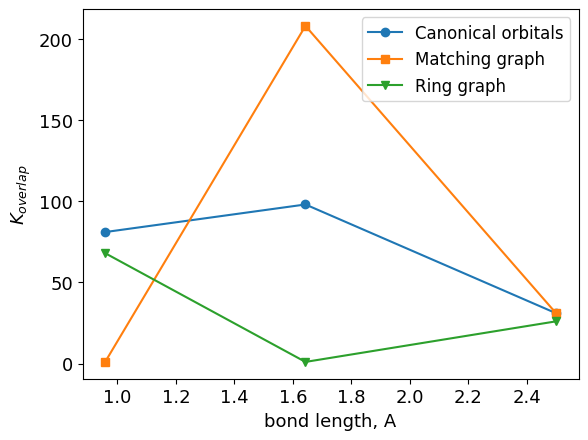

In [106]:
plt.plot(np.sort(no_opt_bonds), np.array(no_opt_K_overlap)[np.argsort(no_opt_bonds)],
        "o-", label="Canonical orbitals")

plt.plot(np.sort(matching_opt_bonds), 
         np.array(matching_opt_K_overlap)[np.argsort(matching_opt_bonds)],
        "s-", label="Matching graph")

plt.plot(np.sort(ring_opt_bonds), 
         np.array(ring_opt_K_overlap)[np.argsort(ring_opt_bonds)],
        "v-", label="Ring graph")

plt.xlabel("bond length, A")
plt.ylabel(r"$K_{overlap}$")
plt.legend(fontsize=12)
plt.savefig("../plots/K_overlap_" + hamiltonian_class + ".png",
           dpi=400, bbox_inches="tight")
plt.show()

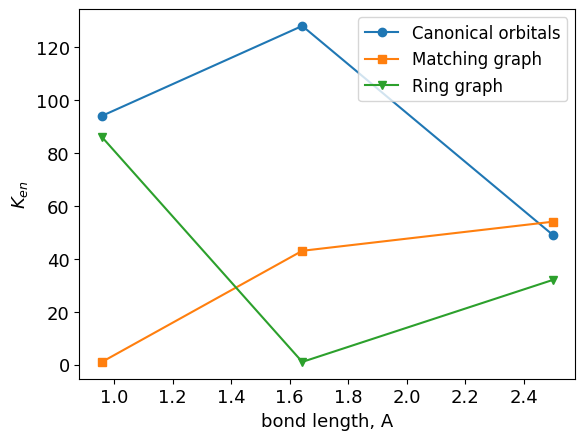

In [107]:
plt.plot(np.sort(no_opt_bonds), np.array(no_opt_K_en)[np.argsort(no_opt_bonds)],
        "o-", label="Canonical orbitals")

plt.plot(np.sort(matching_opt_bonds), 
         np.array(matching_opt_K_en)[np.argsort(matching_opt_bonds)],
        "s-", label="Matching graph")

plt.plot(np.sort(ring_opt_bonds), 
         np.array(ring_opt_K_en)[np.argsort(ring_opt_bonds)],
        "v-", label="Ring graph")

plt.xlabel("bond length, A")
plt.ylabel(r"$K_{en}$")
plt.legend(fontsize=12)
plt.savefig("../plots/K_en_" + hamiltonian_class + ".png",
           dpi=400, bbox_inches="tight")
plt.show()

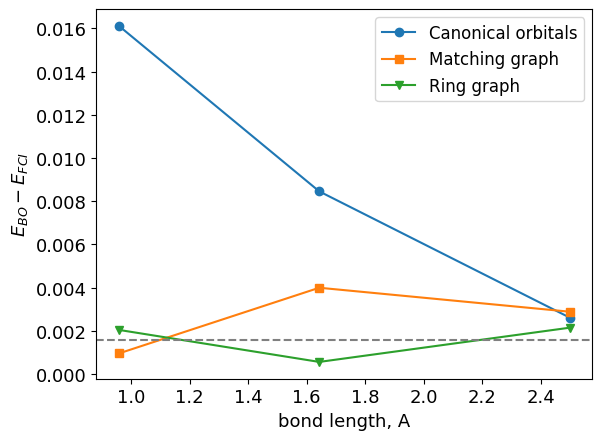

In [108]:
plt.plot(np.sort(no_opt_bonds), no_opt_bo_ens - fci_ens,
        "o-", label="Canonical orbitals")

plt.plot(np.sort(matching_opt_bonds), 
         matching_opt_bo_ens - fci_ens,
        "s-", label="Matching graph")

plt.plot(np.sort(ring_opt_bonds), 
         ring_opt_bo_ens - fci_ens,
        "v-", label="Ring graph")

plt.axhline(0.0016, linestyle="--", color="gray")

plt.xlabel("bond length, A")
plt.ylabel(r"$E_{BO} - E_{FCI}$")
plt.legend(fontsize=12)
plt.savefig("../plots/dE_BO_" + hamiltonian_class + ".png",
           dpi=400, bbox_inches="tight")
plt.show()

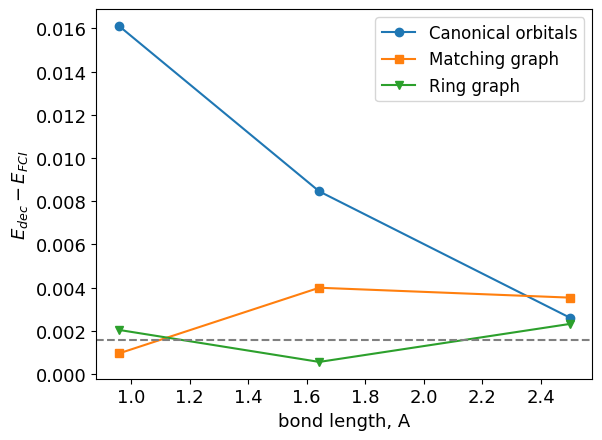

In [109]:
plt.plot(np.sort(no_opt_bonds), no_opt_decoupled_ens - fci_ens,
        "o-", label="Canonical orbitals")

plt.plot(np.sort(matching_opt_bonds), 
         matching_opt_decoupled_ens - fci_ens,
        "s-", label="Matching graph")

plt.plot(np.sort(ring_opt_bonds), 
         ring_opt_decoupled_ens - fci_ens,
        "v-", label="Ring graph")

plt.axhline(0.0016, linestyle="--", color="gray")

plt.xlabel("bond length, A")
plt.ylabel(r"$E_{dec} - E_{FCI}$")
plt.legend(fontsize=12)
plt.savefig("../plots/dE_dec_" + hamiltonian_class + ".png",
           dpi=400, bbox_inches="tight")
plt.show()